In [2]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\T.Rishyendra\OneDrive\Desktop\FUTURE_ML_01\Task1_Sales_Forecasting\Task1_Sales_Forecasting\notebooks
['sales_forecasting.ipynb', 'Sample - Superstore.csv']


In [4]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [8]:
df = df.sort_values('Order Date')

In [9]:
sales_data = df.groupby('Order Date')['Sales'].sum()

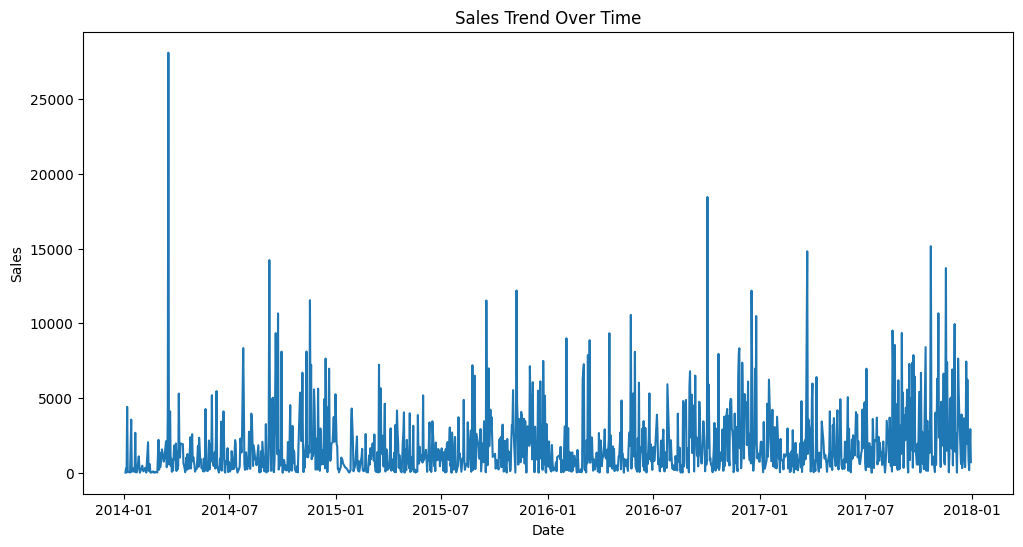

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(sales_data)

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [11]:
sales_data = sales_data.reset_index()
sales_data.columns = ['ds', 'y']

sales_data.head()

,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [12]:
from prophet import Prophet

model = Prophet()

model.fit(sales_data)

Importing plotly failed. Interactive plots will not work.
09:26:02 - cmdstanpy - INFO - Chain [1] start processing
09:26:04 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

In [14]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1262,2018-01-25,1968.169475,-546.864209,4860.377700
1263,2018-01-26,2265.390703,-690.933732,5032.698360
1264,2018-01-27,1894.646638,-922.277353,4706.841046
1265,2018-01-28,2095.572511,-693.873857,4973.842870
1266,2018-01-29,2313.760688,-423.017806,5040.553198


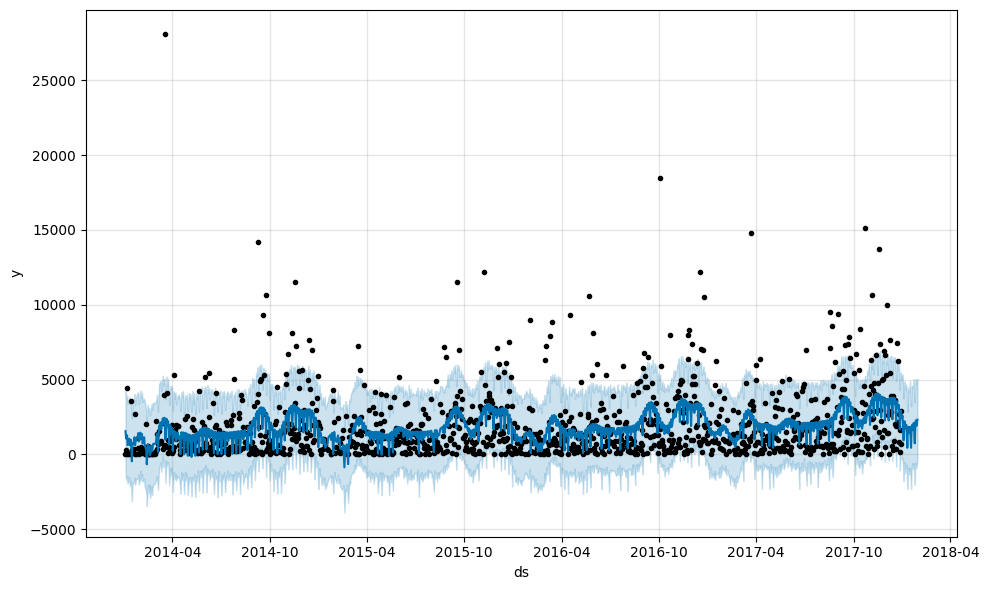

In [15]:
model.plot(forecast)

plt.show()

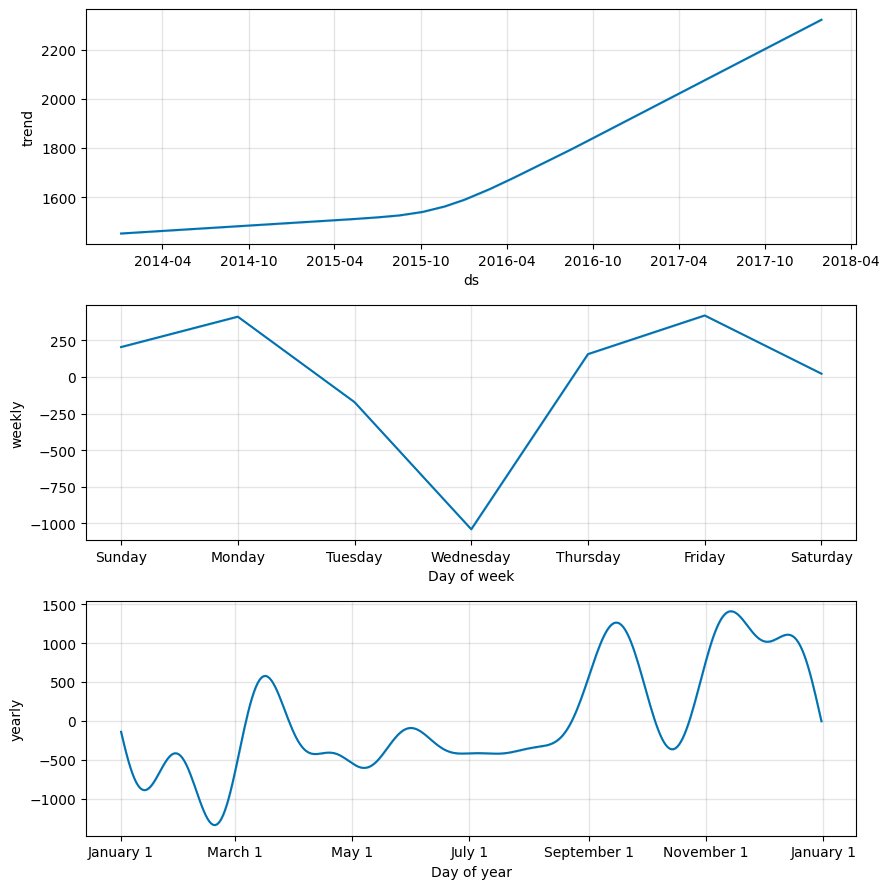

In [16]:
model.plot_components(forecast)

plt.show()

In [17]:
forecast.to_csv("sales_forecast_output.csv", index=False)

print("Forecast file saved successfully")

Forecast file saved successfully


In [1]:
print("Future Interns ML Task Started")

Future Interns ML Task Started
